***IMPORTING INITIAL NECESSARY MODULES AND LIBRARIES***

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report

***LOADING THE DATASET***

In [36]:
df = pd.read_csv('data.csv', sep=';')

***EXPLORING AND ANALYZYING THE DATASET***

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [38]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
for col in df.columns:
    if df[col].dtype == object or df[col].dtype == str:
        print(col)

Target


In [41]:
df['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

***CLEANING COLUMN NAMES BY REMOVING LEADING AND TRAILING WHITESPACE***

In [42]:
df.columns = df.columns.str.strip()

***Calculating The Percentage Distribution Of Students Who Are Financially Up To Date (1) Versus Those Who Are Behind On Payments (0)***

In [43]:
df['Tuition fees up to date'].value_counts()/len(df['Tuition fees up to date'])*100

Tuition fees up to date
1    88.065099
0    11.934901
Name: count, dtype: float64

***FINDING TOP 10 PREDICTORS OF STUDENT DROPOUT***

In [44]:
df['is_Dropout'] = (df['Target']=='Dropout').astype(int)

In [45]:
numeric_df = df.drop('Target', axis=1)

In [46]:
correlations = numeric_df.corr()['is_Dropout'].sort_values(ascending=False)

In [47]:
correlations.head(10)

is_Dropout                                        1.000000
Age at enrollment                                 0.254215
Debtor                                            0.229407
Gender                                            0.203983
Application mode                                  0.198458
Marital status                                    0.093712
Curricular units 2nd sem (without evaluations)    0.079901
Mother's qualification                            0.064958
Curricular units 1st sem (without evaluations)    0.054230
Previous qualification                            0.049379
Name: is_Dropout, dtype: float64

In [48]:
top_features = abs(correlations).sort_values(ascending=False).head(10).index

In [49]:
top_corr_matrix = numeric_df[top_features].corr()

In [50]:
top_corr_matrix

,is_Dropout,Curricular units 2nd sem (grade),Curricular units 2nd sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (approved),Tuition fees up to date,Age at enrollment,Scholarship holder,Debtor,Gender
is_Dropout,1.000000,-0.571792,-0.569500,-0.480669,-0.479112,-0.429149,0.254215,-0.245354,0.229407,0.203983
Curricular units 2nd sem (grade),-0.571792,1.000000,0.760804,0.837170,0.685560,0.296480,-0.173419,0.181227,-0.139424,-0.199133
Curricular units 2nd sem (approved),-0.569500,0.760804,1.000000,0.673335,0.904002,0.291921,-0.112052,0.202704,-0.146977,-0.224266
Curricular units 1st sem (grade),-0.480669,0.837170,0.673335,1.000000,0.696113,0.250394,-0.156616,0.168324,-0.104170,-0.189448
Curricular units 1st sem (approved),-0.479112,0.685560,0.904002,0.696113,1.000000,0.239347,-0.053405,0.153772,-0.106657,-0.183829
Tuition fees up to date,-0.429149,0.296480,0.291921,0.250394,0.239347,1.000000,-0.178099,0.137421,-0.408454,-0.104098
Age at enrollment,0.254215,-0.173419,-0.112052,-0.156616,-0.053405,-0.178099,1.000000,-0.189917,0.098793,0.148835
Scholarship holder,-0.245354,0.181227,0.202704,0.168324,0.153772,0.137421,-0.189917,1.000000,-0.067489,-0.169302
Debtor,0.229407,-0.139424,-0.146977,-0.104170,-0.106657,-0.408454,0.098793,-0.067489,1.000000,0.053812
Gender,0.203983,-0.199133,-0.224266,-0.189448,-0.183829,-0.104098,0.148835,-0.169302,0.053812,1.000000


Text(0.5, 1.0, 'Top 10 Predictors of Student Dropout')

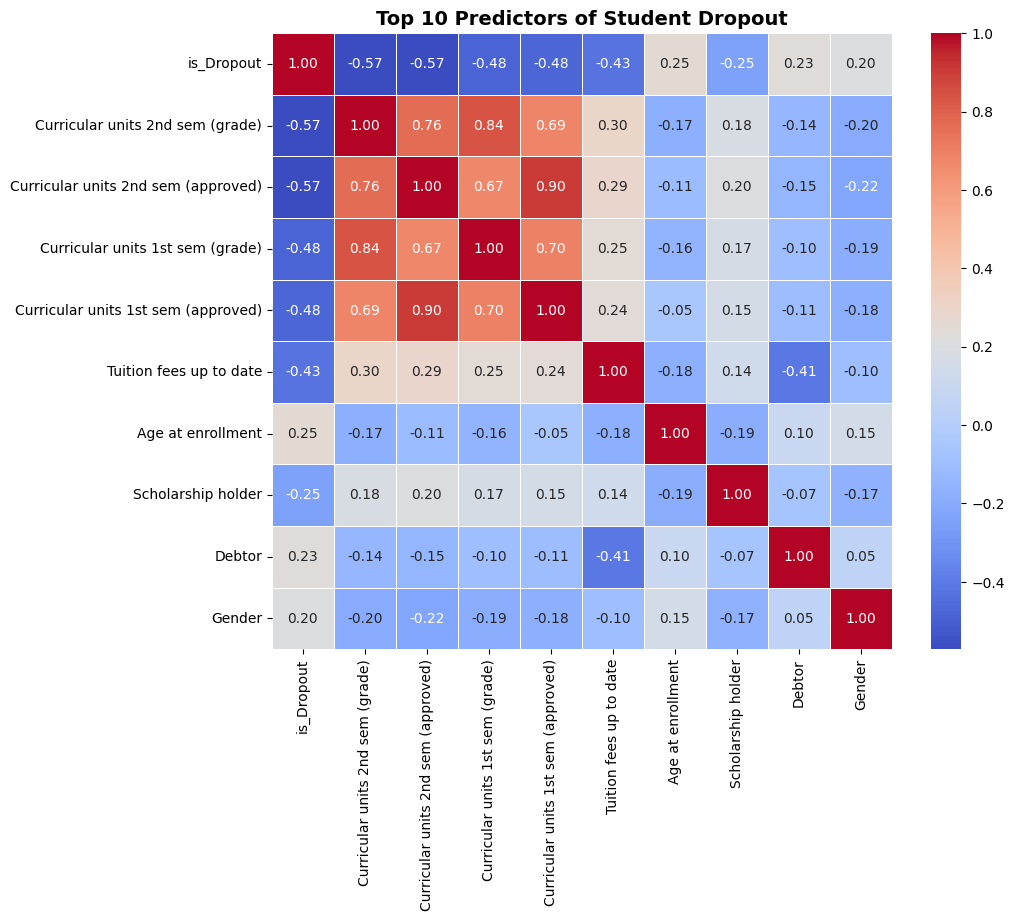

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Top 10 Predictors of Student Dropout", fontsize=14, fontweight='bold')

In [52]:
df.drop(columns='is_Dropout', inplace=True)

***ENCODING THE TARGET COLUMN***

In [53]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Target'] = le.fit_transform(df['Target'])

In [54]:
X = df.drop(columns='Target')
y = df['Target']

***TRAINING , TESTING AND SPLITTING THE DATASET (WITH STRATIFICATION TO PRESERVE THE CLASS DISTRIBUTION)***

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

***GETTING THE BASE RANDOMFOREST'S RESULTS FIRST WITH CLASS_WEIGHT BALANCED!***

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_base_model = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_base_model.fit(X_train, y_train)

y_preds_base_rf = rf_base_model.predict(X_test)

print("BASE RANDOM FOREST'S RESULTS:\n\n",classification_report(y_test, y_preds_base_rf,  target_names=le.classes_))

BASE RANDOM FOREST'S RESULTS:

               precision    recall  f1-score   support

     Dropout       0.81      0.77      0.79       427
    Enrolled       0.57      0.33      0.42       238
    Graduate       0.79      0.93      0.85       663

    accuracy                           0.77      1328
   macro avg       0.72      0.68      0.69      1328
weighted avg       0.76      0.77      0.75      1328



***GETTING THE BASE XGBOOST'S RESULTS FIRST BUT BY BALANCING THE DATA FIRST USING SMOTE***

In [57]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

xgb_base_model = XGBClassifier()

xgb_base_model.fit(X_train_smote, y_train_smote)

y_preds_base_xgb = xgb_base_model.predict(X_test)

print("BASE XGBOOST'S RESULTS:\n\n",classification_report(y_test, y_preds_base_xgb, target_names=le.classes_))

BASE XGBOOST'S RESULTS:

               precision    recall  f1-score   support

     Dropout       0.81      0.73      0.77       427
    Enrolled       0.49      0.53      0.51       238
    Graduate       0.83      0.87      0.85       663

    accuracy                           0.76      1328
   macro avg       0.71      0.71      0.71      1328
weighted avg       0.77      0.76      0.76      1328



In [58]:
from scipy.stats import randint, uniform
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

***TUNING THE XGB MODEL VIA RANDOMIZED SEARCH AND USING CLASS WEIGHT TO BALANCE THE DATA!***

In [59]:
from sklearn.utils.class_weight import compute_sample_weight

weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_pipe = Pipeline([
    ('xgb', XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42))
])

param_dist = {
    'xgb__n_estimators': randint(100, 1000),    # Total trees
    'xgb__max_depth': randint(3, 10),           # Depth of each tree
    'xgb__gamma': uniform(0, 0.5),              # Minimum loss reduction to split
    
    'xgb__learning_rate': uniform(0.01, 0.3),   # Step size shrinkage

    'xgb__subsample': uniform(0.6, 0.4),        # % of rows used per tree
    'xgb__colsample_bytree': uniform(0.6, 0.4), # % of features used per tree
    
    'xgb__reg_alpha': uniform(0, 1),            # L1 regularization
    'xgb__reg_lambda': uniform(1, 2)            # L2 regularization
}

In [60]:
xgb_random = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=20, 
    cv=5, 
    scoring='f1_macro',
    random_state=42,
    n_jobs = -1 
)

xgb_random.fit(X_train, y_train)

print(f"Best Parameters: {xgb_random.best_params_}")
y_best_preds = xgb_random.predict(X_test)

print("TUNED XGB'S RESULTS:\n\n",classification_report(y_test, y_best_preds, target_names=le.classes_))

Best Parameters: {'xgb__colsample_bytree': np.float64(0.8083337040103294), 'xgb__gamma': np.float64(0.48058601217467456), 'xgb__learning_rate': np.float64(0.2633601546034454), 'xgb__max_depth': 7, 'xgb__n_estimators': 437, 'xgb__reg_alpha': np.float64(0.5396921323890798), 'xgb__reg_lambda': np.float64(2.1735023313276964), 'xgb__subsample': np.float64(0.9861021229056552)}
TUNED XGB'S RESULTS:

               precision    recall  f1-score   support

     Dropout       0.83      0.75      0.78       427
    Enrolled       0.54      0.46      0.50       238
    Graduate       0.81      0.91      0.86       663

    accuracy                           0.78      1328
   macro avg       0.73      0.71      0.71      1328
weighted avg       0.77      0.78      0.77      1328



***TUNING THE RANDOM FOREST MODEL VIA RANDOMIZED SEARCH AND USING SMOTE TO BALANCE THE DATA AT EACH FOLD!***

In [61]:
rf_pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_dict = {
    'rf__n_estimators': randint(100, 1000),
    'rf__max_depth': [None] + list(np.arange(10, 50, 5)),
    'rf__max_features': uniform(0.1, 0.7),
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf': randint(1, 10),
    'rf__bootstrap': [True],
    'rf__oob_score': [True],
    'smote__k_neighbors': randint(1, 8)
}

In [62]:
rf_random = RandomizedSearchCV(
    estimator = rf_pipe,
    param_distributions = param_dict,
    n_iter = 20, 
    cv = 5,      
    scoring = 'f1_weighted',
    n_jobs = -1,
    verbose = 1,
    random_state = 42
)

rf_random.fit(X_train, y_train)

print(f"Optimal Parameters: {rf_random.best_params_}")
best_model = rf_random.best_estimator_

y_tuned_preds = best_model.predict(X_test)

print("TUNED RANDOM FOREST'S RESULTS:\n\n",classification_report(y_test, y_tuned_preds, target_names=le.classes_))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Optimal Parameters: {'rf__bootstrap': True, 'rf__max_depth': np.int64(40), 'rf__max_features': np.float64(0.29230525509304495), 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 2, 'rf__n_estimators': 838, 'rf__oob_score': True, 'smote__k_neighbors': 5}
TUNED RANDOM FOREST'S RESULTS:

               precision    recall  f1-score   support

     Dropout       0.85      0.71      0.77       427
    Enrolled       0.49      0.59      0.54       238
    Graduate       0.84      0.87      0.85       663

    accuracy                           0.77      1328
   macro avg       0.73      0.72      0.72      1328
weighted avg       0.78      0.77      0.77      1328



***COMPARING THE IMPORTANCE OF FEATURES FROM BOTH TUNED MODELS!***

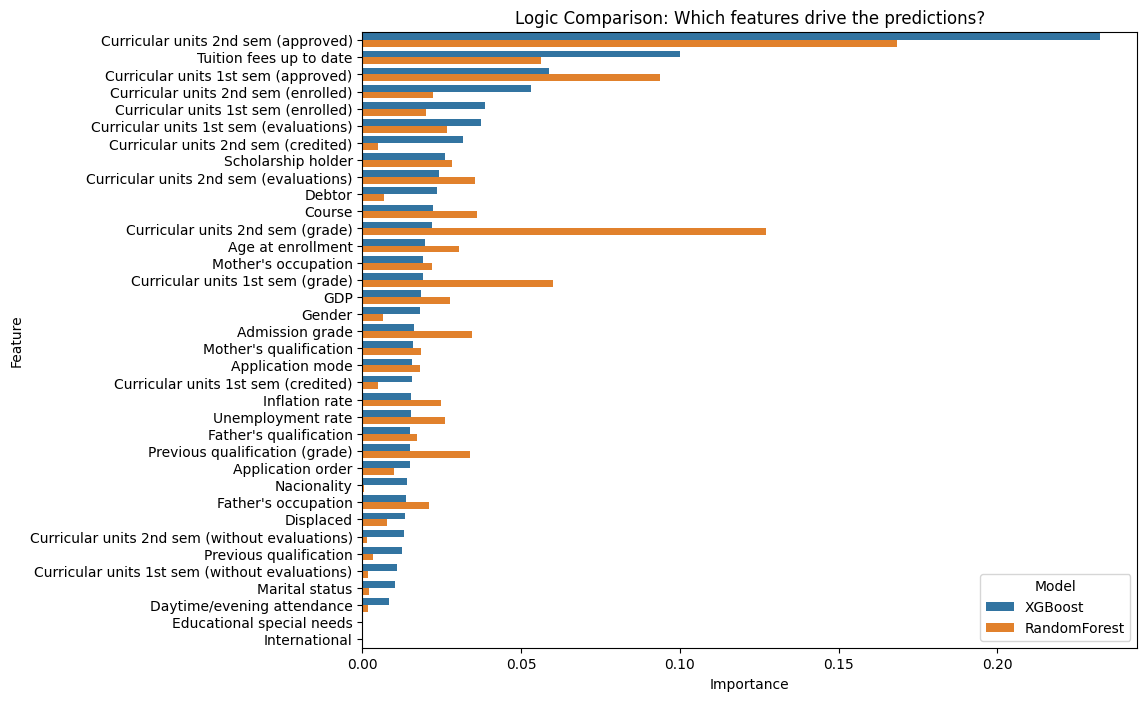

In [63]:
# 1. Extracting Feature Importance from XGBoost (Weighted)
xgb_importances = xgb_random.best_estimator_.named_steps['xgb'].feature_importances_

# 2. Extracting Feature Importance from Random Forest (SMOTE)
rf_importances = rf_random.best_estimator_.named_steps['rf'].feature_importances_

# Creating a DataFrame for plotting
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'XGBoost': xgb_importances,
    'RandomForest': rf_importances
}).sort_values(by='XGBoost', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 8))
feat_df_melted = feat_df.melt(id_vars='Feature', var_name='Model', value_name='Importance')
sns.barplot(data=feat_df_melted, y='Feature', x='Importance', hue='Model')
plt.title('Logic Comparison: Which features drive the predictions?')
plt.show()

***CREATING THE CONFUSION MATRIX OF THE PREDICTIONS FROM BOTH TUNED MODELS!***

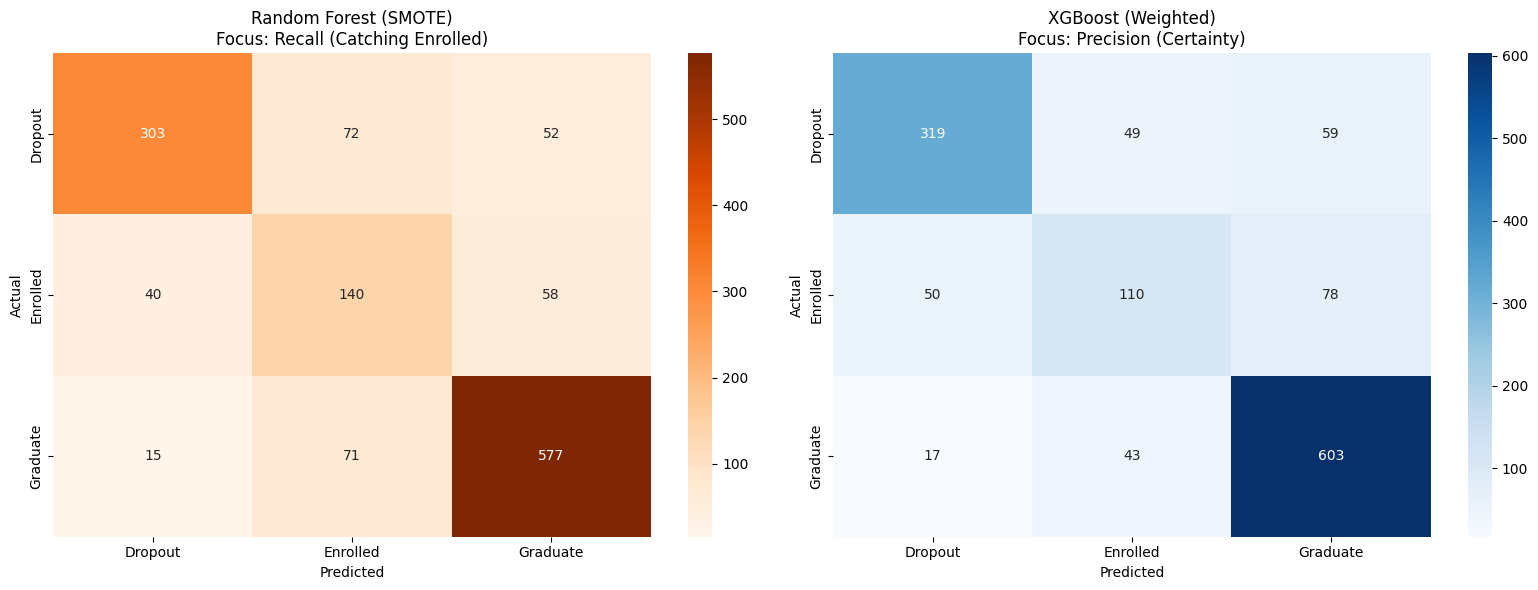

In [64]:
from sklearn.metrics import confusion_matrix

# 1. Get predictions from both tuned models
rf_preds = rf_random.best_estimator_.predict(X_test)
xgb_preds = xgb_random.best_estimator_.predict(X_test)

# 2. Define the classes for the labels
class_names = le.classes_ # ['Dropout', 'Enrolled', 'Graduate']

# 3. Creating the Plotting Logic
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plotting Random Forest (SMOTE)
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=ax[0],
            xticklabels=class_names, yticklabels=class_names)
ax[0].set_title('Random Forest (SMOTE)\nFocus: Recall (Catching Enrolled)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Plotting XGBoost (Weighted)
cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names, yticklabels=class_names)
ax[1].set_title('XGBoost (Weighted)\nFocus: Precision (Certainty)')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**THANK YOU**